# 003 · Validación del bloque hueco de concreto (cavidad de aire) vs Borbón

**Track 1 del plan `VALIDATION.md`** — validación física del módulo 2D de
EnerHabitat (`System2D` + `HollowBlock`, `Fill.AIR`) contra la resistencia
térmica experimental de **Borbón et al. (2010)** (`pdfs/Borbon.pdf`).

El bloque hueco es un problema **2D con transferencia acoplada**: conducción en
la cáscara/puentes de concreto, **convección de Nusselt** y **radiación** entre
las paredes de la cavidad. EnergyPlus resuelve muros en 1D y *no* puede ser la
referencia física de la cavidad; **Borbón (placa caliente protegida, ASTM C177)
sí lo es**.

**Referencia de validación:** la `R` **medida** (Tabla 3 del paper, 7 corridas,
incertidumbre experimental **±3.75 %**), con $R\in[0.15,0.19]\;\mathrm{°C\,m^2/W}$.
Como Borbón **no midió la k** de sus bloques, EnerHabitat se corre con la banda
$k \in [0.90, 1.35]$ W/m·K y nominal $k=1.1$ (Cengel 2004, el valor del modelo
de Borbón, `pdfs/Borbon_modelo_2010.pdf`).

**El "hackeo" de EnerHabitat (validado en de-risk):** se reduce el solver a un
régimen estacionario tipo placa caliente con
1. **EPW plano** → `Tsa` constante (T constante, solar 0, `absortance=0`);
2. **`ho`, `hi` grandes** → superficies fijadas (Dirichlet, como la placa);
3. **`solveAC(setpoint)`** → aire interior fijo; `q` de la energía integrada.

$$ q=\dfrac{Q_\text{cool}+Q_\text{heat}}{N\,\Delta t},\qquad
   R=\dfrac{T_{so}-T_{si}}{q},\qquad \bar T=\tfrac{T_{so}+T_{si}}{2} $$

Las temperaturas de superficie se toman del **campo estacionario** `Tfield`
(media física por cara), evitando el factor de reporte $n_x/(n_x-1)$ de las
series `Tso/Tsi` del solver.

**Orden del estudio:** (1) **converger la malla** — refinar hasta que `R` cambie
< 5 %; (2) con esa malla, ejecutar **toda** la validación de Borbón.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import enerhabitat as eh

eh.config.file = "materials.ini"           # cwd = notebooks/
SRC_EPW = "../epw/Temixco_2018CST.epw"      # solo se usa su encabezado
FLAT_EPW = "_flat_driver.epw"               # EPW plano temporal

# --- Material: Borbón NO midió la k de sus bloques; su modelo usó k=1.1 W/m·K
# (Cengel 2004; pdfs/Borbon_modelo_2010.pdf). Se toma 1.1 como NOMINAL y una
# banda plausible para concreto seco ~1800 kg/m³ (los bloques se secaron 24 h a
# 100 °C): 0.90 (límite bajo, concreto seco) – 1.35 (valor genérico de
# materials.ini). En estacionario rho y c no intervienen: solo k importa.
MAT    = "ConcretoBorbon"                   # k = 1.10 (nominal)
MAT_LO = "ConcretoBorbon_k090"              # k = 0.90 -> R más ALTA
MAT_HI = "ConcretoBorbon_k135"              # k = 1.35 -> R más BAJA

# --- Geometría del bloque de Borbón (celda unitaria = 1 cavidad) ---
# La celda de EH es [a11 | cavidad | a12/2] con lados adiabáticos (planos de
# simetría): el muro periódico resultante alterna almas de 2*a11 y a12. El
# bloque real (Fig. 5) tiene 3 almas de 24 mm por 2 cavidades y en las juntas
# los extremos suman 48 mm -> el patrón real alterna almas de 24 y 48 mm.
# Con a11=0.012 y a12=0.048 la celda lo reproduce EXACTO: X=0.2 m, 36 mm de
# concreto por cavidad (18 %), igual que el muro de Borbón (72 mm/400 mm).
GEOMETRY = {"web": 0.012, "a12": 0.048, "block_width": 0.164,
            "cover_top": 0.025, "cavity": 0.07, "cover_bottom": 0.025}
EMIS = 0.9                                  # emisividad usada por Borbón
HUGE = 1e4                                  # ho=hi grandes -> superficies fijadas

# Punto de referencia para converger la malla = corrida 1 de Borbón (Tabla 2).
T_HOT_REF, T_COLD_REF = 42.34, 28.76

# Malla 2D (nx, ny) = (nodos en ANCHO x, nodos en ESPESOR y). Es la RESOLUCIÓN y
# SOLO depende de config2d (NO de la geometría): dx=X/nx, dy=Y/ny. Las paredes de
# la cavidad se "pegan" a los nodos (truncamiento entero en compute_mesh), así que
# se usan mallas CONMENSURABLES (X=0.2 m -> nx múltiplo de 50, ny múltiplo de 120)
# -> cavidad exacta 164.0 x 70.0 mm y convergencia limpia. Valor inicial
# provisional; la malla definitiva la fija el estudio de convergencia.
eh.config2d.nx, eh.config2d.ny = 50, 120

print("EnerHabitat", eh.__version__)
print("espesor del bloque =",
      eh.HollowBlock(MAT, geometry=GEOMETRY).thickness, "m  (Borbón: 0.12)")

EnerHabitat 0.4.0
espesor del bloque = 0.12 m  (Borbón: 0.12)


In [2]:
# --- Encabezado EPW real -> generador de EPW plano (T constante, solar 0) ---
with open(SRC_EPW) as f:
    _HEAD = [next(f) for _ in range(8)]

def flat_epw(path, T):
    """Escribe un EPW de 24 h con dry-bulb=T constante y radiación solar=0."""
    L = list(_HEAD)
    for h in range(24):
        row = ["2025", "5", "15", str(h + 1), "60", "_",
               f"{T:.3f}", "0", "23", "100000"] + ["0"] * 25
        L.append(",".join(row) + "\n")
    with open(path, "w") as g:
        g.writelines(L)

def R_EH(T_hot, T_cold, mat=None, emis=EMIS, mesh=None, ho=HUGE, hi=HUGE):
    """R estacionario superficie-a-superficie del bloque con cavidad de aire.
    Exterior caliente (EPW plano) = T_hot; interior frío (setpoint AC) = T_cold.
    `mat` elige la k del concreto (None -> MAT nominal; MAT_LO/MAT_HI extremos).
    Si mesh=None usa la malla actual de config2d (la convergida); si se pasa
    mesh=(nx,ny) la fija para esta llamada."""
    if mesh is not None:
        eh.config2d.nx, eh.config2d.ny = mesh
    eh.config2d.max_days = 60
    eh.config.ho, eh.config.hi = ho, hi
    flat_epw(FLAT_EPW, T_hot)
    blk = eh.HollowBlock(mat or MAT, fill_type=eh.Fill.AIR,
                         emissivity=emis, geometry=GEOMETRY)
    s = eh.System2D(eh.Location(FLAT_EPW))
    s.tilt, s.azimuth, s.absortance = 90, 90, 0.0
    s.layers = [blk]
    s.location.meanDay(month=5, year=2025)
    s.setpoint = T_cold
    s.solveAC()
    F = s.Tfield                            # campo estacionario (último día)
    Tso, Tsi = float(F[:, 0].mean()), float(F[:, -1].mean())
    period = len(s.solve_dataframe) * eh.config.dt
    q = (s.cooling_energy + s.heating_energy) / period
    dT, Tp = abs(Tso - Tsi), (Tso + Tsi) / 2
    return dict(Tso=Tso, Tsi=Tsi, dT=dT, Tprom=Tp, q=q, R=dT / q, days=int(s.days))

## Geometría: sección del bloque a escala

Mapeo Borbón → `HollowBlock`: espesor (flujo) `cover_top+cavity+cover_bottom`
= 0.025+0.07+0.025 = **0.12 m**; cavidad 0.07 m; recubrimientos 0.025 m;
ancho de cavidad 0.164 m.

**Almas (Fig. 5 de Borbón):** el bloque de 0.40 m tiene 3 almas de 0.024 m por
2 cavidades; al juntar bloques (pegamento epóxico, sin mortero) los extremos
suman 0.048 m. El muro real alterna almas de **24 y 48 mm** → 36 mm de concreto
por cavidad (fracción sólida 72/400 = 18 %). La celda de EH `[a11 | cavidad |
a12/2]` con lados adiabáticos (simetría) lo reproduce exacto con `a11=0.012`
(media alma central) y `a12=0.048` (alma de junta): X = 0.2 m.

2D section  50×120   X=200.0 mm  Y=120.0 mm   dx=4.082  dy=1.008 mm
Block/cavity: i∈[3,43)  j∈[24,94)
Node types (NT):
    NT  0  air             2800 nodes
    NT  1  corner             1 nodes
    NT  2  corner             1 nodes
    NT  3  corner             1 nodes
    NT  4  corner             1 nodes
    NT  5  outer edge        48 nodes
    NT  6  side             118 nodes
    NT  7  side             118 nodes
    NT  8  inner edge        48 nodes
    NT  9  top wall          40 nodes
    NT 10  bottom wall       40 nodes
    NT 11  left wall         70 nodes
    NT 12  right wall        70 nodes
    NT 13  interior        2644 nodes
Assigned materials (by k, ρc):
    ConcretoBorbon                 3200 nodes   y∈[0.0,121.0] mm  (k=1.1, ρc=1.8e+06)
    Air (cavity)                   2800 nodes   y∈[24.2,94.8] mm


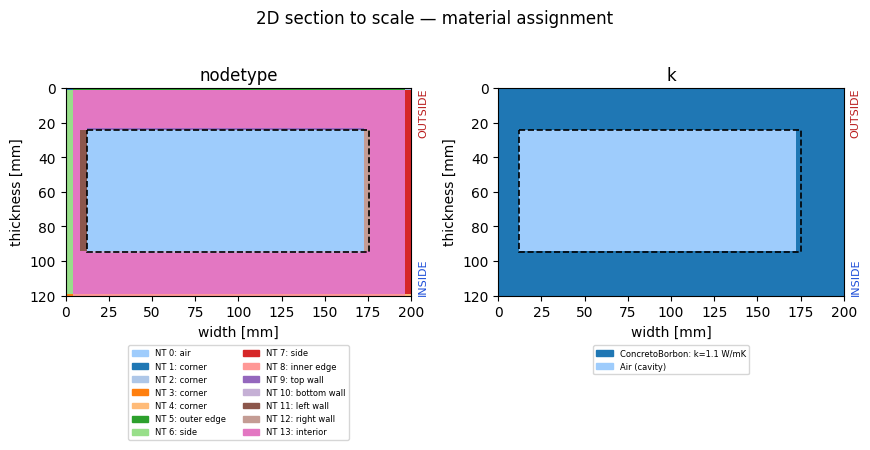

In [3]:
blk = eh.HollowBlock(MAT, fill_type=eh.Fill.AIR,
                     emissivity=EMIS, geometry=GEOMETRY)
wall = eh.System2D(eh.Location(SRC_EPW)); wall.tilt = 90; wall.layers = [blk]
wall.section_report()
wall.preview(panels=["nodetype", "k"]);

## Paso 1 — Convergencia de malla (refinar hasta ΔR < 5 %)

Se refina la malla (conmensurable: cavidad exacta 164×70 mm, almas exactas
12/24 mm) en el punto de referencia (corrida 1 de Borbón) y se verifica que `R`
no cambie más de **5 %** entre refinamientos. Se adopta como malla de producción
la **cuadrada isótropa `200×120`** (`dx=dy=1 mm`), que se fija en `config2d` y
la usa **toda** la validación siguiente.

In [4]:
TOL = 0.05                                   # 5 %
PROD_MESH = (200, 120)                        # cuadrada isótropa (dx=dy=1mm), exacta
mesh_seq = [(50, 120), (100, 240), PROD_MESH]
rows, R_prev = [], None
t0 = time.time()
for m in mesh_seq:
    d = R_EH(T_HOT_REF, T_COLD_REF, mesh=m)
    chg = np.nan if R_prev is None else 100 * abs(d["R"] - R_prev) / R_prev
    rows.append((f"{m[0]}x{m[1]}", 200/m[0], 120/m[1], d["dT"], d["R"], chg))
    R_prev = d["R"]
conv_df = pd.DataFrame(rows, columns=["malla", "dx", "dy", "dT", "R_EH", "Δ% vs previa"])
ok = (conv_df["Δ% vs previa"].dropna() < 100 * TOL).all()

eh.config2d.nx, eh.config2d.ny = PROD_MESH    # <-- malla definitiva para Borbón
print(f"({time.time()-t0:.0f}s)  Convergencia ΔR<5%: {'OK' if ok else 'NO'}"
      f"   -> malla de producción {PROD_MESH[0]}x{PROD_MESH[1]} fijada en config2d")
conv_df.round({"dx": 2, "dy": 2, "dT": 2, "R_EH": 4, "Δ% vs previa": 2})

AttributeError: 'System2D' object has no attribute 'solve_dataframe'

## Paso 2 — Validación contra Borbón (con la malla convergida)

### Track 1a — Los 7 puntos de operación de Borbón, con banda de k

Se alimentan las **temperaturas de superficie reales** de la Tabla 2 (cara
caliente `TEI`, cara fría `TED`) y se compara contra la **`R` medida (Tabla 3)**,
que tiene incertidumbre experimental de **±3.75 %**.

Como la k del concreto **no fue medida**, cada punto se corre 3 veces:
`k=0.90` (cota alta de R), `k=1.10` (nominal, el valor del modelo de Borbón) y
`k=1.35` (cota baja de R). La validación se evalúa con el nominal
(`err_meas_%`) y con la pregunta de si la medición cae **dentro de la banda**
`[R(k=1.35), R(k=0.90)]` (`en_banda_k`). Todas las corridas usan la malla
convergida (`config2d` ya fijado arriba).

Nota: la corrida 3 de la Tabla 3 reporta T̄=30.71 °C pero de la Tabla 2 sale
(50.82+30.57)/2 = 40.70 °C (errata aparente; aquí se usa el valor calculado).

In [ ]:
# Borbón Tabla 2 (T de superficie) + Tabla 3 (R medida, A=2.4 m²)
U_EXP = 0.0375                               # incertidumbre experimental de Borbón ±3.75 %
BORBON = pd.DataFrame([
    # run, TEI(cal), TED(frío), q_W,   dTmuro, Tprom,  R_meas
    (1, 42.34, 28.76, 187.28, 13.58, 35.55, 0.174),
    (2, 41.60, 24.72, 224.47, 16.88, 33.16, 0.180),
    (3, 50.82, 30.57, 269.95, 20.05, 30.71, 0.178),
    (4, 40.07, 16.76, 325.20, 23.31, 28.42, 0.172),
    (5, 59.34, 32.41, 391.49, 26.93, 45.88, 0.165),
    (6, 63.46, 33.30, 411.06, 30.16, 48.38, 0.176),
    (7, 61.56, 21.73, 571.37, 39.83, 41.65, 0.167),
], columns=["run", "TEI", "TED", "q_W", "dTmuro", "Tprom", "R_meas"])

print(f"malla en uso: {eh.config2d.nx}x{eh.config2d.ny}")
rows = []
t0 = time.time()
for _, b in BORBON.iterrows():
    n  = R_EH(b.TEI, b.TED)                   # k = 1.10 nominal
    lo = R_EH(b.TEI, b.TED, mat=MAT_HI)       # k = 1.35 -> R más baja
    hi = R_EH(b.TEI, b.TED, mat=MAT_LO)       # k = 0.90 -> R más alta
    rows.append((int(b.run), n["dT"], n["Tprom"], n["q"], b.q_W / 2.4,
                 lo["R"], n["R"], hi["R"], b.R_meas))
res = pd.DataFrame(rows, columns=["run", "dT", "Tprom", "q", "q_meas",
                                  "R_k135", "R_EH", "R_k090", "R_meas"])
res["err_meas_%"] = 100 * (res.R_EH - res.R_meas) / res.R_meas
res["dentro_exp"] = res["err_meas_%"].abs() <= 100 * U_EXP
res["en_banda_k"] = (res.R_meas >= res.R_k135) & (res.R_meas <= res.R_k090)
print(f"({time.time()-t0:.0f}s)")
res.round({"dT":2,"Tprom":2,"q":1,"q_meas":1,"R_k135":4,"R_EH":4,"R_k090":4,
           "R_meas":3,"err_meas_%":1})

In [ ]:
print(f"R_EH (k=1.10)    : {res.R_EH.min():.3f} – {res.R_EH.max():.3f} °C·m²/W"
      f"   (Borbón: 0.15 – 0.19)")
print(f"MAE vs medición  : {res['err_meas_%'].abs().mean():.2f} %"
      f"   (incertidumbre exp. de Borbón: ±{100*U_EXP:.2f} %)")
print(f"puntos dentro de ±{100*U_EXP:.2f} % (k nominal): {int(res.dentro_exp.sum())}/{len(res)}")
print(f"medición dentro de la banda k 0.90–1.35: {int(res.en_banda_k.sum())}/{len(res)}")
print(f"Tendencia R(ΔT)  : R={'baja' if res.R_EH.iloc[-1]<res.R_EH.iloc[0] else 'sube'}"
      f" al crecer ΔT  ({res.R_EH.iloc[0]:.3f} -> {res.R_EH.iloc[-1]:.3f})")

### Figura 8 (réplica): $R$ vs $\Delta T$

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.axhspan(0.15, 0.19, color="0.9", label="banda Borbón (0.15–0.19)")
o = res.sort_values("dT")
ax.fill_between(o.dT, o.R_k135, o.R_k090, color="C0", alpha=0.18,
                label="EnerHabitat, banda k=0.90–1.35 W/m·K")
ax.scatter(res.dT, res.R_EH, marker="o", s=70, color="C0",
           label="R EnerHabitat 2D (k=1.10 nominal)", zorder=3)
ax.errorbar(res.dT, res.R_meas, yerr=U_EXP * res.R_meas, fmt="s", ms=8,
            color="C3", capsize=3, ls="none",
            label="R experimental (Tabla 3) ±3.75 %", zorder=3)
ax.set_xlabel("ΔT del muro [°C]"); ax.set_ylabel("R [°C·m²/W]")
ax.set_title("Resistencia térmica del bloque hueco — EnerHabitat vs Borbón")
ax.set_ylim(0.13, 0.21); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout()

### Sensibilidad a la emisividad de la cavidad (0.8 – 0.95)

Borbón nota que los coeficientes de radiación dependen del acabado superficial.
La radiación domina parte del intercambio en la cavidad → `R` sube al bajar ε.

In [ ]:
emis_rows = []
for e in [0.80, 0.85, 0.90, 0.95]:
    d = R_EH(T_HOT_REF, T_COLD_REF, emis=e)  # malla convergida
    emis_rows.append((e, d["dT"], d["Tprom"], d["R"]))
emis_df = pd.DataFrame(emis_rows, columns=["emisividad", "dT", "Tprom", "R_EH"])
emis_df.round(4)

## Conclusiones — Track 1

Criterios de aceptación (`VALIDATION.md`); la referencia es la **medición** de
Borbón (Tabla 3, ±3.75 % de incertidumbre experimental):

| Métrica | Criterio | Resultado |
|---|---|---|
| Convergencia de malla | ΔR < 5 % al refinar | ver Paso 1 |
| `R_EH` en banda física | 0.15–0.19 °C·m²/W | ver Track 1a |
| **`R_EH` (k=1.10) vs medición** | ≤ ±10 % | ver MAE |
| Medición dentro de la banda de k | banda k=0.90–1.35 cubre `R_meas` | ver `en_banda_k` |
| Tendencia R(ΔT) | R↓ al crecer ΔT | ver Track 1a |

**Configuración física — sin parámetros ajustados:** `ε = 0.9` (valor de
Borbón) y celda unitaria con las almas **exactas** de la Fig. 5 (patrón
alternante 24/48 mm, 18 % de concreto). La k del concreto **no fue medida por
Borbón**, por lo que se propaga como banda de incertidumbre
`k ∈ [0.90, 1.35]` W/m·K con nominal `k = 1.10` (Cengel 2004, el valor del
modelo de Borbón; `pdfs/Borbon_modelo_2010.pdf`) — en estacionario ρ y c no
intervienen. La sensibilidad a la emisividad (0.80–0.95) se reporta aparte.